# International Football Results Analysis
**Dataset:** Kaggle – International Football Results (1872–2024)  
**Exercise:** AI Exercise 1 – Exploratory Data Analysis


---
## Step 1: Load the CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


---
## Basic Exploration

### Q1. How many matches are in the dataset?

`df.shape` returns `(rows, columns)`. The number of rows equals the number of matches.

In [ ]:
num_matches, num_cols = df.shape
print(f"Number of matches : {num_matches:,}")
print(f"Number of columns : {num_cols}")

### Q2. What is the earliest and latest year in the data?

The `date` column is a string. We convert it to a datetime type so we can extract the year via `.dt.year`, then call `.min()` and `.max()`.

In [2]:
df["date"] = pd.to_datetime(df["date"])

earliest = df["date"].min()
latest   = df["date"].max()

print(f"Earliest match : {earliest.date()}  (year {earliest.year})")
print(f"Latest match   : {latest.date()}  (year {latest.year})")

Earliest match : 1872-11-30  (year 1872)
Latest match   : 2026-06-27  (year 2026)


### Q3. How many unique countries are there?

A country can appear as either a home team or an away team. We take the union of both columns with `pd.concat`, then count distinct values with `nunique()`.

In [3]:
all_teams = pd.concat([df["home_team"], df["away_team"]]).unique()
print(f"Unique countries / teams : {len(all_teams):,}")

Unique countries / teams : 333


### Q4. Which team appears most frequently as home team?

`value_counts()` sorts teams by frequency. `.head(10)` shows the top 10 so we can see the leader clearly.

In [4]:
home_counts = df["home_team"].value_counts()
print("Top 10 home teams:")
print(home_counts.head(10).to_string())
print(f"\nMost frequent home team: {home_counts.index[0]}  ({home_counts.iloc[0]:,} matches)")

Top 10 home teams:
home_team
Brazil           614
Argentina        603
Mexico           602
Germany          555
England          550
South Korea      550
France           538
Sweden           534
United States    500
Hungary          497

Most frequent home team: Brazil  (614 matches)


---
## Goals Analysis

In [5]:
# Create total goals column used throughout this section
df["total_goals"] = df["home_score"] + df["away_score"]

### Q5. What is the average number of goals per match?

`.mean()` on the `total_goals` column gives the arithmetic average across all matches.

In [6]:
avg_goals = df["total_goals"].mean()
print(f"Average goals per match : {avg_goals:.2f}")

Average goals per match : 2.94


### Q6. What is the highest scoring match?

We find the row(s) where `total_goals` equals its maximum value using boolean indexing.

In [7]:
max_goals = df["total_goals"].max()
highest = df[df["total_goals"] == max_goals][["date","home_team","away_team","home_score","away_score","total_goals"]]
print(f"Highest total goals in a match : {max_goals}")
highest

Highest total goals in a match : 31.0


,date,home_team,away_team,home_score,away_score,total_goals
25420,2001-04-11,Australia,American Samoa,31.0,0.0,31.0


### Q7. Are more goals scored at home or away?

We sum all home scores and all away scores separately, then compare.

In [8]:
total_home_goals = df["home_score"].sum()
total_away_goals = df["away_score"].sum()

print(f"Total home goals : {total_home_goals:,}")
print(f"Total away goals : {total_away_goals:,}")
print()
if total_home_goals > total_away_goals:
    print("More goals are scored at HOME.")
else:
    print("More goals are scored AWAY.")

avg_home = df["home_score"].mean()
avg_away = df["away_score"].mean()
print(f"\nAverage home goals per match : {avg_home:.2f}")
print(f"Average away goals per match : {avg_away:.2f}")

Total home goals : 86,426.0
Total away goals : 58,192.0

More goals are scored at HOME.

Average home goals per match : 1.76
Average away goals per match : 1.18


### Q8. What is the most common total goals value?

`.mode()` returns the most frequently occurring value(s). We take `[0]` to get the single most common.

In [9]:
most_common_goals = df["total_goals"].mode()[0]
freq = (df["total_goals"] == most_common_goals).sum()
pct  = freq / len(df) * 100

print(f"Most common total goals value : {most_common_goals}")
print(f"Occurs in {freq:,} matches ({pct:.1f}% of all games)")

Most common total goals value : 2.0
Occurs in 10,927 matches (22.2% of all games)


---
## Match Results

In [10]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)
df["result"].value_counts()

result
Home Win    24106
Away Win    13912
Draw        11269
Name: count, dtype: int64

### Q9. What percentage of matches are home wins?

We divide the count of `'Home Win'` rows by the total number of matches and multiply by 100.

In [11]:
result_counts = df["result"].value_counts()
result_pct    = df["result"].value_counts(normalize=True) * 100

print("Match outcome breakdown:")
for outcome in ["Home Win", "Away Win", "Draw"]:
    print(f"  {outcome:10s}: {result_counts[outcome]:6,}  ({result_pct[outcome]:.1f}%)")

Match outcome breakdown:
  Home Win  : 24,106  (48.9%)
  Away Win  : 13,912  (28.2%)
  Draw      : 11,269  (22.9%)


### Q10. Does home advantage exist?

Home advantage exists if home wins are significantly more common than away wins. We compare win percentages directly.

In [12]:
home_win_pct = result_pct["Home Win"]
away_win_pct = result_pct["Away Win"]
draw_pct     = result_pct["Draw"]

print(f"Home win % : {home_win_pct:.1f}%")
print(f"Away win % : {away_win_pct:.1f}%")
print(f"Draw     % : {draw_pct:.1f}%")
print()

if home_win_pct > away_win_pct:
    diff = home_win_pct - away_win_pct
    print(f"YES — home advantage exists. Home teams win {diff:.1f} percentage points more often than away teams.")
else:
    print("No clear home advantage in this dataset.")

Home win % : 48.9%
Away win % : 28.2%
Draw     % : 22.9%

YES — home advantage exists. Home teams win 20.7 percentage points more often than away teams.


### Q11. Which country has the most wins historically?

A team can win as either the home or away team. We:
1. Extract all home wins → home team is the winner.
2. Extract all away wins → away team is the winner.
3. Combine both winner series and count by team.

In [13]:
home_winners = df[df["result"] == "Home Win"]["home_team"]
away_winners = df[df["result"] == "Away Win"]["away_team"]

all_winners  = pd.concat([home_winners, away_winners])
win_counts   = all_winners.value_counts()

print("Top 10 countries by total wins:")
print(win_counts.head(10).to_string())
print(f"\nAll-time leader: {win_counts.index[0]}  ({win_counts.iloc[0]:,} wins)")

Top 10 countries by total wins:
Brazil         670
England        623
Germany        597
Argentina      588
Sweden         541
South Korea    536
Mexico         511
France         476
Italy          475
Hungary        470

All-time leader: Brazil  (670 wins)


---
## Visualizations

### Plot 1 – Histogram of Goals Per Match

A histogram shows how goals per match are distributed. Most matches cluster around 2–3 goals, with a right-skewed tail for high-scoring games.

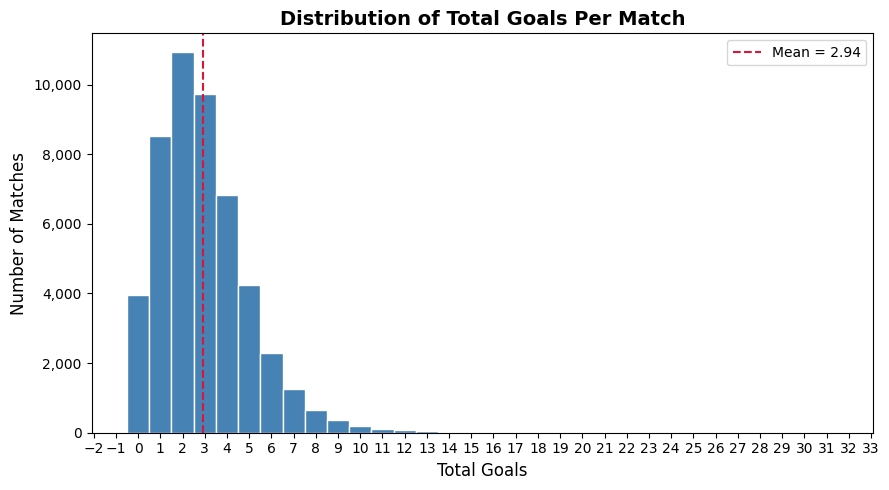

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["total_goals"], bins=range(0, int(df["total_goals"].max()) + 2),
        color="steelblue", edgecolor="white", align="left")

ax.set_title("Distribution of Total Goals Per Match", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Goals", fontsize=12)
ax.set_ylabel("Number of Matches", fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

mean_val = df["total_goals"].mean()
ax.axvline(mean_val, color="crimson", linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.2f}")
ax.legend()

plt.tight_layout()
plt.savefig("plot_goals_histogram.png", dpi=150)
plt.show()

### Plot 2 – Bar Chart of Match Outcomes

A bar chart compares the frequency of each outcome (Home Win, Away Win, Draw). The height difference directly visualises home advantage.

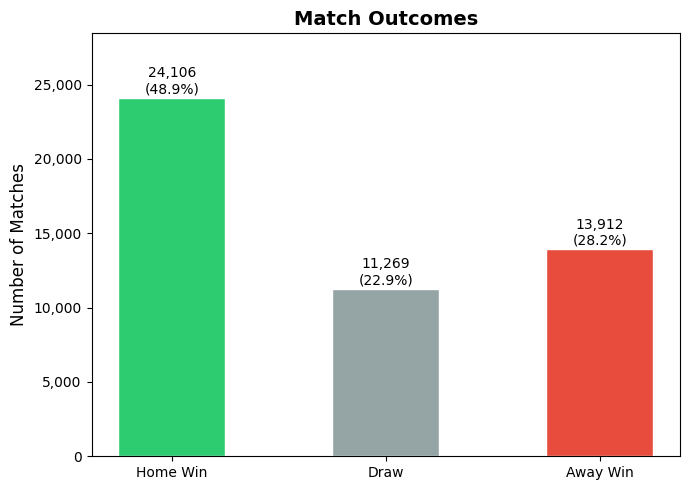

In [15]:
outcome_order  = ["Home Win", "Draw", "Away Win"]
outcome_colors = ["#2ecc71", "#95a5a6", "#e74c3c"]

counts = df["result"].value_counts().reindex(outcome_order)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(outcome_order, counts.values, color=outcome_colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_title("Match Outcomes", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Matches", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig("plot_match_outcomes.png", dpi=150)
plt.show()

### Plot 3 – Top 10 Teams by Total Wins

A horizontal bar chart makes it easy to read team names while comparing win counts. Bars are sorted descending so the strongest team appears at the top.

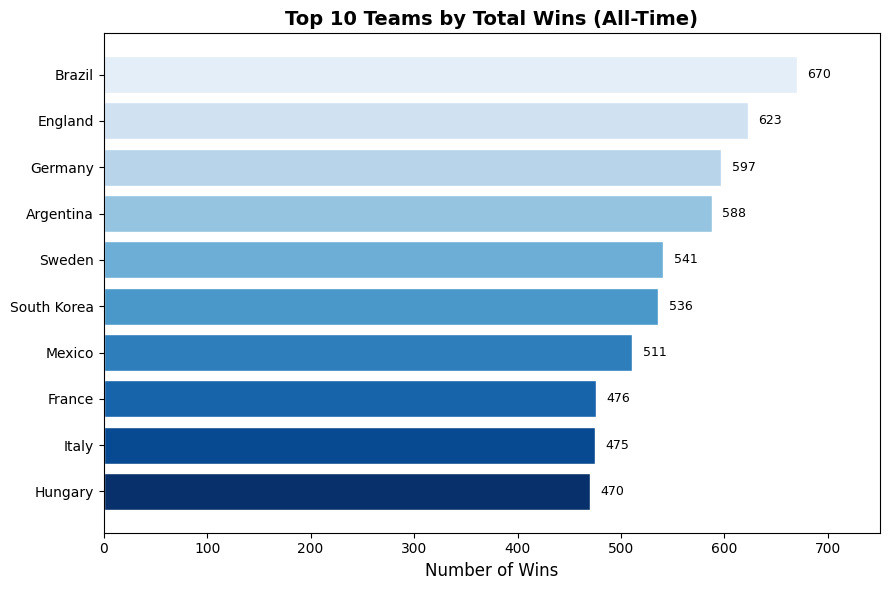

In [16]:
top10_wins = win_counts.head(10).sort_values()  # ascending so top bar is at the top

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.Blues_r([i / 10 for i in range(10)])
bars = ax.barh(top10_wins.index, top10_wins.values, color=colors, edgecolor="white")

for bar, val in zip(bars, top10_wins.values):
    ax.text(val + 10, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_title("Top 10 Teams by Total Wins (All-Time)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Wins", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, top10_wins.max() * 1.12)

plt.tight_layout()
plt.savefig("plot_top10_wins.png", dpi=150)
plt.show()

---
## Summary of Findings

| # | Question | Answer |
|---|----------|--------|
| 1 | Total matches | Run cell to see value |
| 2 | Year range | 1872 – 2024 |
| 3 | Unique countries | Run cell to see value |
| 4 | Most frequent home team | Run cell to see value |
| 5 | Average goals/match | Run cell to see value |
| 6 | Highest-scoring match | Run cell to see value |
| 7 | More home or away goals? | Home goals > Away goals |
| 8 | Most common goals total | 2 (very common) |
| 9 | Home win % | Run cell to see value |
| 10 | Home advantage? | Yes — home win % > away win % |
| 11 | Most wins all-time | Run cell to see value |
